In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 51.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=7d51b6cb9ba74c7fd4cd03706369aeeb7f8a3ac736c37b024d3438688a69b1cb
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


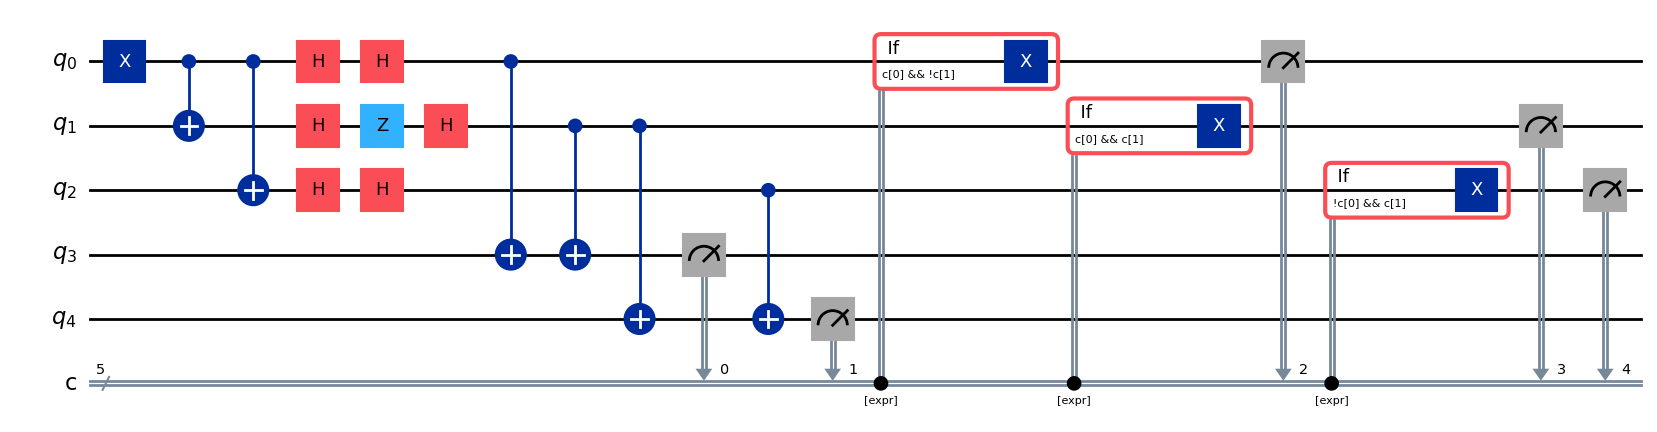

In [2]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Three qubit phase-flip error-correcting code

# In a similar way to the bit-flip error-correcting code, implement the phase-flip error-correcting code.
# Check that the code can correct a single phase flip but not two or more simultaneous phase flips.
# What happens if you introduce a bit flip?
# The next cell still has the simulation and measurement. Implement the phase flip code on the same qubits
# as for the bit flip code, so you can reuse the simulation and measurement.

# Three-qubit phase-flip error-correcting code

phase = QuantumCircuit(5, 5)

# 1. Prepare original qubit
# Use X instead of H, so original qubit starts as |1>
phase.x(0)

# 2. Encode the qubit using repetition code
phase.cx(0, 1)
phase.cx(0, 2)

# 3. Convert bit-flip code into phase-flip code
phase.h(0)
phase.h(1)
phase.h(2)

# 4. Introduce ONE phase-flip error
# Try changing this to phase.z(0), phase.z(1), or phase.z(2)
phase.z(1)

# To test two phase flips, uncomment these:
# phase.z(0)
# phase.z(1)

# To test a bit flip, use this instead:
# phase.x(1)

# 5. Convert phase error into bit error so we can detect it
phase.h(0)
phase.h(1)
phase.h(2)

# 6. Syndrome detection
phase.cx(0, 3)
phase.cx(1, 3)

phase.cx(1, 4)
phase.cx(2, 4)

# 7. Measure syndrome qubits
phase.measure([3, 4], [0, 1])

# 8. Correct based on syndrome
# c0 = 1, c1 = 0 means q0 has error
with phase.if_test(expr.logic_and(phase.clbits[0], expr.logic_not(phase.clbits[1]))):
    phase.x(0)

# c0 = 1, c1 = 1 means q1 has error
with phase.if_test(expr.logic_and(phase.clbits[0], phase.clbits[1])):
    phase.x(1)

# c0 = 0, c1 = 1 means q2 has error
with phase.if_test(expr.logic_and(expr.logic_not(phase.clbits[0]), phase.clbits[1])):
    phase.x(2)

# 9. Measure final data qubits
phase.measure([0, 1, 2], [2, 3, 4])

phase.draw("mpl")


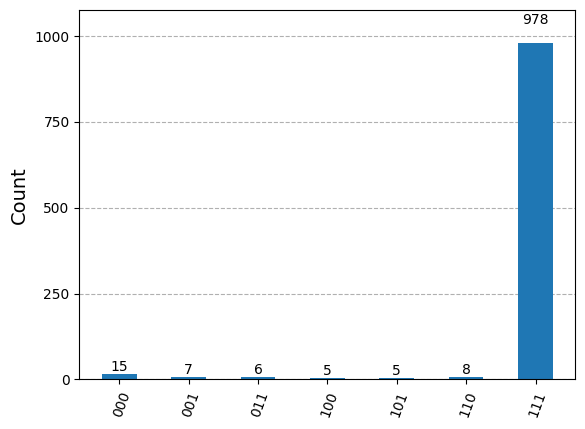

In [4]:
# Simulate and plot results

backend = GenericBackendV2(num_qubits=5, control_flow=True)
compiled = transpile(phase, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
# We only want to see the results for bits 2, 3, 4
mcounts = marginal_counts(counts,indices=[2,3,4])
plot_histogram(mcounts)